In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [89]:
data = pd.read_csv('cleaned_fuelo_data.csv')
data

,№,Седмица,Бензин A95,Дизел,Пропан Бутан
0,1,30.12 - 05.01.20,2.22,2.28,0.95
1,2,06.01 - 12.01.20,2.22,2.28,0.95
2,3,13.01 - 19.01.20,2.23,2.28,0.96
3,4,20.01 - 26.01.20,2.23,2.28,0.97
4,5,27.01 - 02.02.20,2.23,2.28,0.98
...,...,...,...,...,...
309,49,01.12 - 07.12.25,2.43,2.50,1.12
310,50,08.12 - 14.12.25,2.43,2.50,1.12
311,51,15.12 - 21.12.25,2.43,2.49,1.12
312,52,22.12 - 28.12.25,2.42,2.47,1.13


In [90]:
# Add column for year
data["year"] = (
    data["Седмица"]
    .str[-2:]
    .astype(int)
)

data["year"] += 2000

In [91]:
data = data[data["year"] <= 2025].copy()
data

,№,Седмица,Бензин A95,Дизел,Пропан Бутан,year
0,1,30.12 - 05.01.20,2.22,2.28,0.95,2020
1,2,06.01 - 12.01.20,2.22,2.28,0.95,2020
2,3,13.01 - 19.01.20,2.23,2.28,0.96,2020
3,4,20.01 - 26.01.20,2.23,2.28,0.97,2020
4,5,27.01 - 02.02.20,2.23,2.28,0.98,2020
...,...,...,...,...,...,...
308,48,24.11 - 30.11.25,2.43,2.51,1.11,2025
309,49,01.12 - 07.12.25,2.43,2.50,1.12,2025
310,50,08.12 - 14.12.25,2.43,2.50,1.12,2025
311,51,15.12 - 21.12.25,2.43,2.49,1.12,2025


In [92]:
data["start_date"] = (
    data["Седмица"]
    .str.split(" - ")
    .str[0] + "." +
    data["Седмица"].str[-2:]
)

data["start_date"] = pd.to_datetime(
    data["start_date"],
    format="%d.%m.%y"
)

In [93]:
exchange_rate = 1.95583
price_cols = data.columns[2:-2]

data.loc[data.index, price_cols] = (
    data.loc[data.index, price_cols] / exchange_rate
)

In [96]:
data

,№,Седмица,Бензин A95,Дизел,Пропан Бутан,year,start_date
0,1,30.12 - 05.01.20,1.135068,1.165745,0.485727,2020,2020-12-30
1,2,06.01 - 12.01.20,1.135068,1.165745,0.485727,2020,2020-01-06
2,3,13.01 - 19.01.20,1.140181,1.165745,0.490840,2020,2020-01-13
3,4,20.01 - 26.01.20,1.140181,1.165745,0.495953,2020,2020-01-20
4,5,27.01 - 02.02.20,1.140181,1.165745,0.501066,2020,2020-01-27
...,...,...,...,...,...,...,...
308,48,24.11 - 30.11.25,1.242439,1.283343,0.567534,2025,2025-11-24
309,49,01.12 - 07.12.25,1.242439,1.278230,0.572647,2025,2025-12-01
310,50,08.12 - 14.12.25,1.242439,1.278230,0.572647,2025,2025-12-08
311,51,15.12 - 21.12.25,1.242439,1.273117,0.572647,2025,2025-12-15


In [94]:
data[['Бензин A95', 'Дизел', 'Пропан Бутан']].describe()

,Бензин A95,Дизел,Пропан Бутан
count,313.000000,313.000000,313.000000
mean,1.254380,1.283702,0.587757
std,0.199224,0.227732,0.098453
min,0.858970,0.884535,0.393695
25%,1.140181,1.160633,0.531744
50%,1.278230,1.278230,0.598212
75%,1.360036,1.416279,0.639115
max,1.738392,1.820199,0.823180


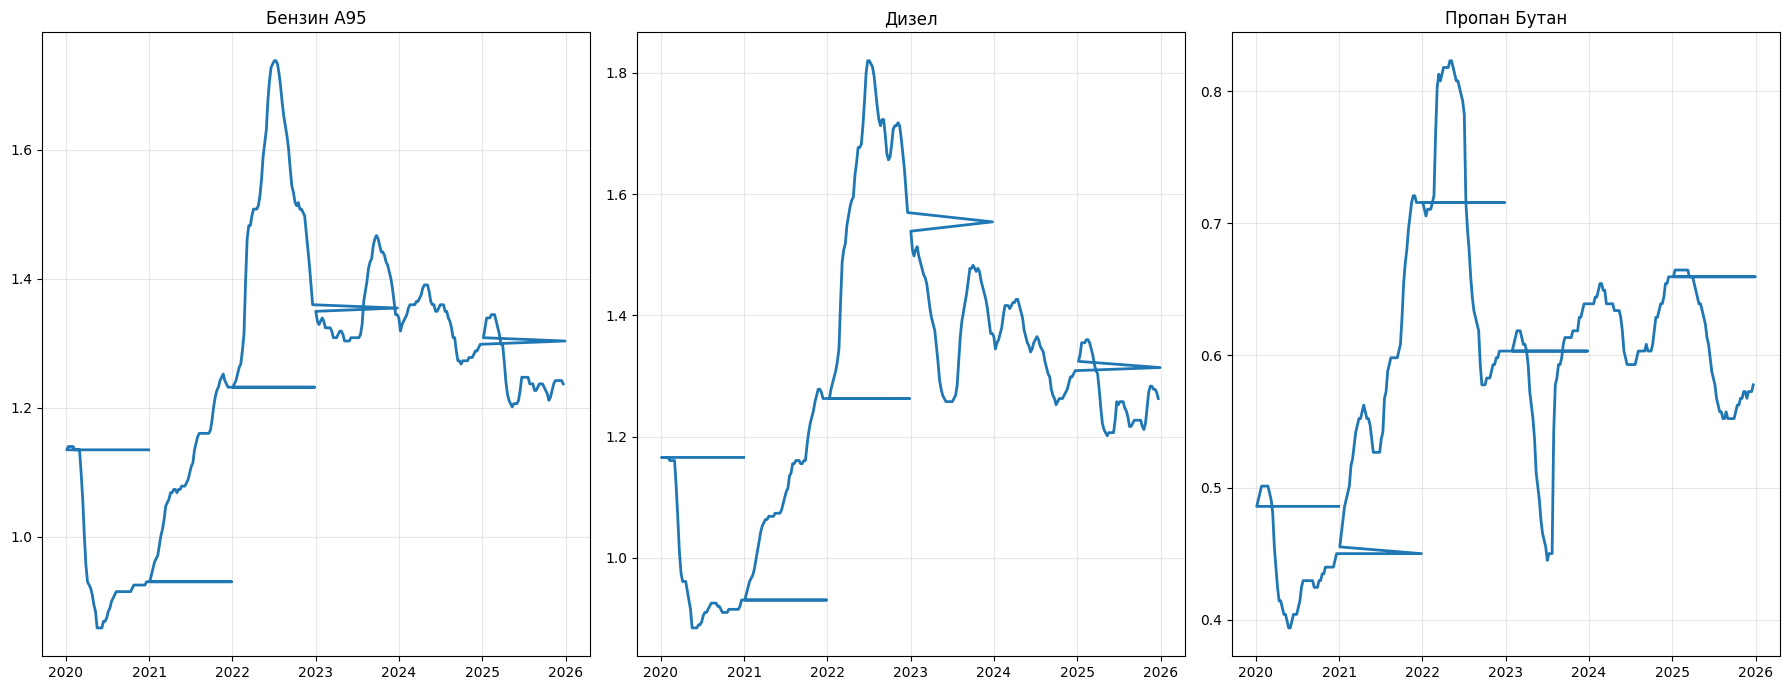

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True)

columns = ["Бензин A95", "Дизел", "Пропан Бутан"]

for ax, col in zip(axes, columns):
    ax.plot(data["start_date"], data[col], linewidth=2)
    ax.set_title(col)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()